In [44]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
import scipy.spatial as spatial
import scipy.cluster as clstr
from collections import defaultdict
import operator
from pathlib import Path

In [45]:
project_dir = Path.cwd().parent
print(project_dir.name)

chessify


In [46]:
img = cv2.imread(project_dir / "notebooks" / "game_opera_side" / "game_opera_20.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

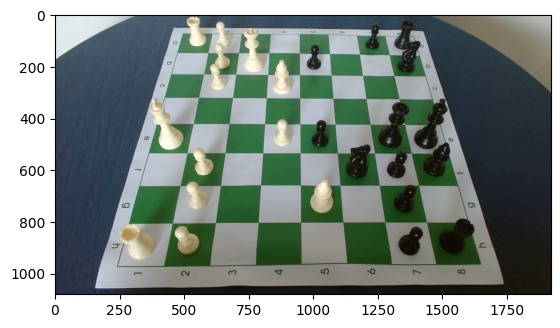

In [47]:
plt.imshow(img)

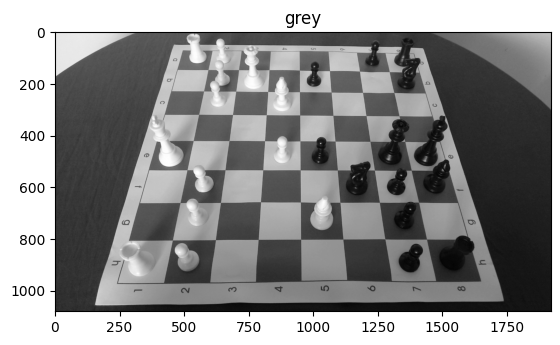

In [48]:
grey = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
plt.title("grey")
plt.imshow(grey, cmap = "grey")

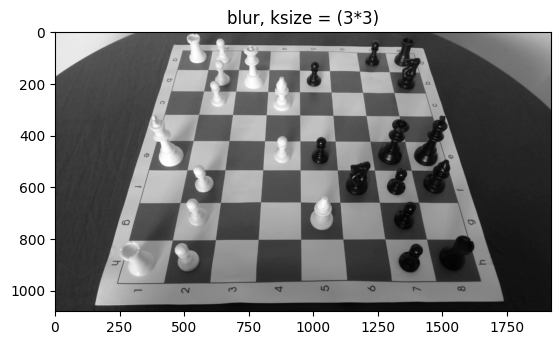

In [49]:
blur = cv2.blur(grey, (3, 3))
plt.title("blur, ksize = (3*3)")
plt.imshow(blur, cmap = "grey")

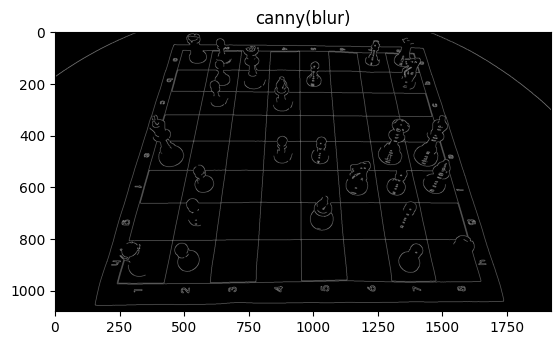

In [50]:
v = np.median(blur)
sigma = 0.33
l = int(max(0, (1.0 - sigma) * v))
u = int(min(255, (1.0 + sigma) * v))
canny = cv2.Canny(blur, l, u)
plt.title("canny(blur)")
plt.imshow(canny, cmap = "grey")

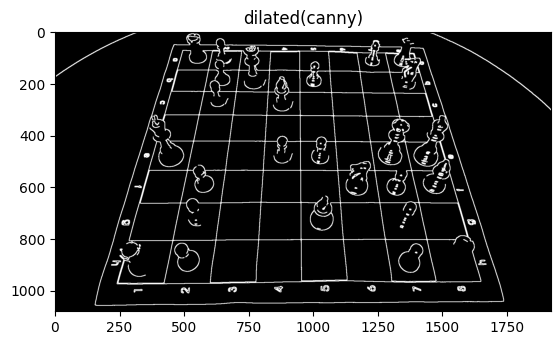

In [51]:
kernel = np.ones((3, 3), np.uint8)
dilated = cv2.dilate(canny, kernel, iterations = 1)
plt.title("dilated(canny)")
plt.imshow(dilated, cmap = "grey")

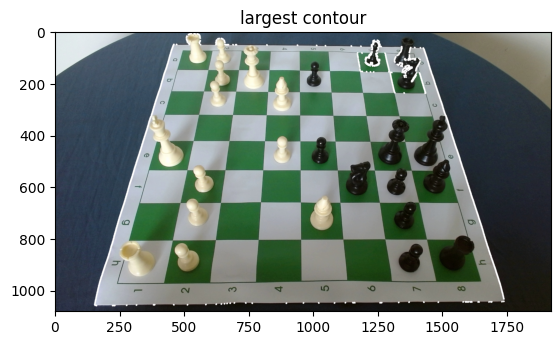

In [52]:
cnts, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(cnts, key=cv2.contourArea)
base = img.copy()
cv2.drawContours(base, largest_contour, -1, (255, 255, 255), 5)
plt.title("largest contour")
plt.imshow(base, cmap = 'grey')   

In [53]:
def find_corners(points):
    #max x + y
    bottom_right, _ = max(enumerate([point[0] + point[1] for point in points]), key=operator.itemgetter(1))
    #min x + y
    top_left, _ = min(enumerate([point[0] + point[1] for point in points]), key=operator.itemgetter(1))
    #min x - y
    bottom_left, _ = min(enumerate([point[0] - point[1] for point in points]), key=operator.itemgetter(1))
    #max x - y
    top_right, _ = max(enumerate([point[0] - point[1] for point in points]), key=operator.itemgetter(1))
    return [points[top_left], points[top_right], points[bottom_left], points[bottom_right]]

board_corners = find_corners(largest_contour[:, 0, :])
board_corners

[array([459,  51], dtype=int32),
 array([1423,   66], dtype=int32),
 array([ 154, 1057], dtype=int32),
 array([1733, 1043], dtype=int32)]

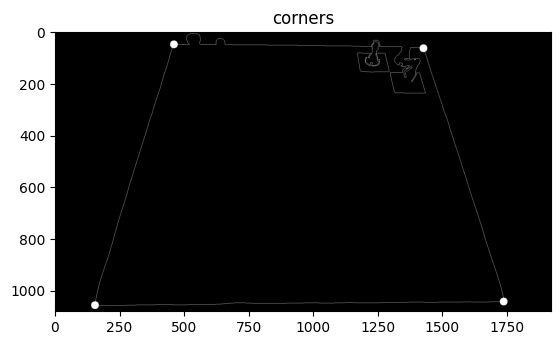

In [54]:
h, w, l = img.shape
corners_image = np.zeros((h, w, 3), np.uint8)
cv2.drawContours(corners_image, [largest_contour], -1, (255, 255, 255), 1)

cv2.circle(corners_image, board_corners[0], 15, (255, 255, 255), -1)  # red for top-left
cv2.circle(corners_image, board_corners[1], 15, (255, 255, 255), -1)  # green for top-right
cv2.circle(corners_image, board_corners[2], 15, (255, 255,255), -1)  # blue for bottom-left
cv2.circle(corners_image, board_corners[3], 15, (255, 255, 255), -1)  # yellow for bottom-right


board_corners = np.asarray(board_corners, dtype = "float32")
plt.title("corners")
plt.imshow(corners_image, cmap="gray")

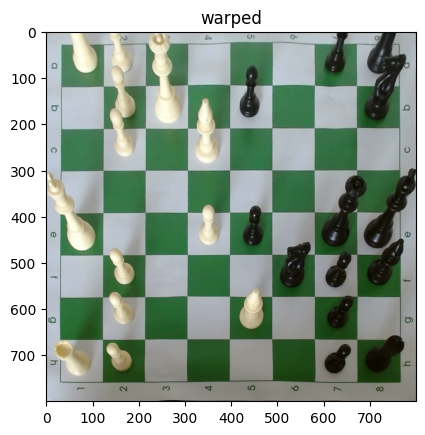

In [55]:
height, width = 800, 800
dimensions = np.float32([[0, 0],[width, 0], [0, height],[width, height]])
M = cv2.getPerspectiveTransform(board_corners, dimensions)
M_inv = cv2.invert(M)[1]
board = cv2.warpPerspective(img, M, (width, height))
plt.title("warped")
plt.imshow(board)

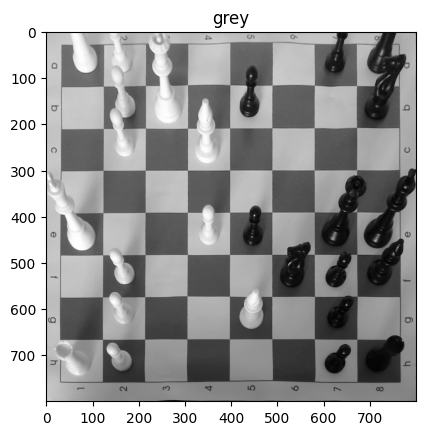

In [56]:
base = board.copy()
grey = cv2.cvtColor(board, cv2.COLOR_RGB2GRAY)
plt.title("grey")
plt.imshow(grey, cmap = "gray")

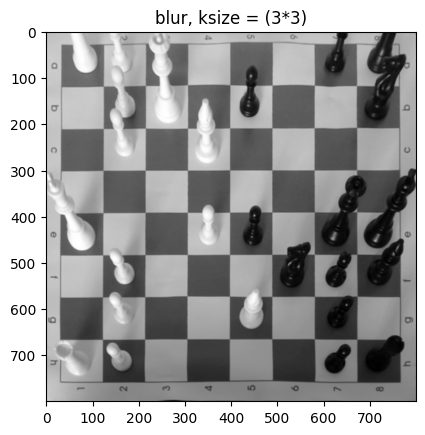

In [57]:
blur = cv2.blur(grey, (3, 3))
plt.title("blur, ksize = (3*3)")
plt.imshow(blur, cmap = "grey")

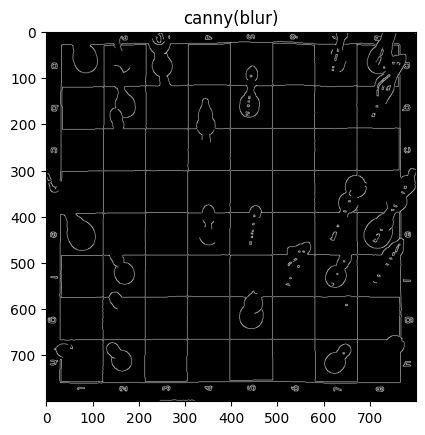

In [58]:
v = np.median(blur)
l = int(max(0, (1.0 - sigma) * v))
u = int(min(255, (1.0 + sigma) * v))
canny = cv2.Canny(blur, l, u)
plt.title("canny(blur)")
plt.imshow(canny, cmap = "grey")

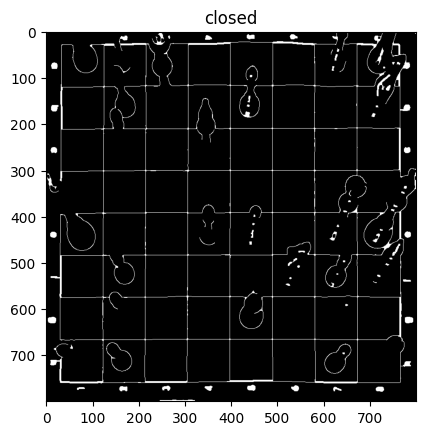

In [59]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
closed = cv2.morphologyEx(canny, cv2.MORPH_CLOSE, kernel)
plt.title("closed")
plt.imshow(closed, cmap = "grey")

In [60]:
def drawHough(lines, image):
    for line in lines:
        rho = line[0][0]
        theta = line[0][1]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a*rho
        y0 = b*rho
        x1 = int(x0 + 1000*(-b))
        y1 = int(y0 + 1000*(a))
        x2 = int(x0 - 1000*(-b))
        y2 = int(y0 - 1000*(a))
        cv2.line(image, (x1, y1), (x2, y2), (0, 0, 255), 2)    

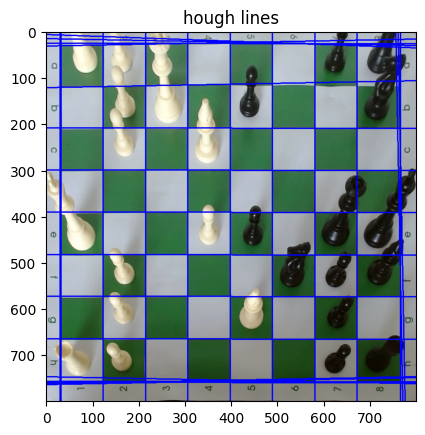

In [61]:
base = board.copy()
lines = cv2.HoughLines(closed, 1, np.pi/180, 180)
drawHough(lines, base)
plt.title("hough lines")
plt.imshow(base)

In [62]:
lines = np.reshape(lines, (-1, 2))
h = []
v = []
for rho, theta in lines:
    if theta < np.pi / 4 or theta > np.pi - np.pi/4:
        v.append([rho, theta])
    else:
        h.append([rho, theta])

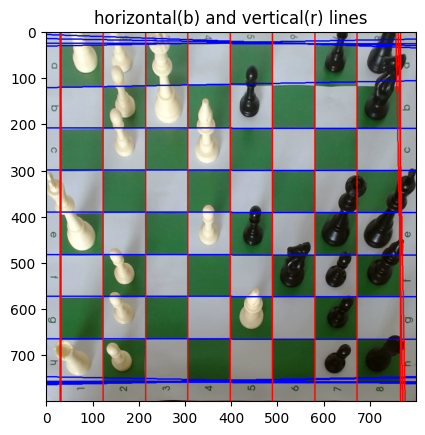

In [63]:
base = board.copy()
for line in h:
    rho = line[0]
    theta = line[1]
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a*rho
    y0 = b*rho
    x1 = int(x0 + 1000*(-b))
    y1 = int(y0 + 1000*(a))
    x2 = int(x0 - 1000*(-b))
    y2 = int(y0 - 1000*(a))
    cv2.line(base, (x1, y1), (x2, y2), (0, 0, 255), 2)
for line in v:
    rho = line[0]
    theta = line[1]
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a*rho
    y0 = b*rho
    x1 = int(x0 + 1000*(-b))
    y1 = int(y0 + 1000*(a))
    x2 = int(x0 - 1000*(-b))
    y2 = int(y0 - 1000*(a))
    cv2.line(base, (x1, y1), (x2, y2), (255, 0, 0), 2)
plt.title("horizontal(b) and vertical(r) lines")
plt.imshow(base)

In [64]:
points = []
for rho_h, theta_h in h:
    for rho_v, theta_v in v:
        a = np.array([[np.cos(theta_h), np.sin(theta_h)], [np.cos(theta_v), np.sin(theta_v)]])
        b = np.array([rho_h, rho_v])
        intersect = np.linalg.solve(a, b)
        points.append(intersect)

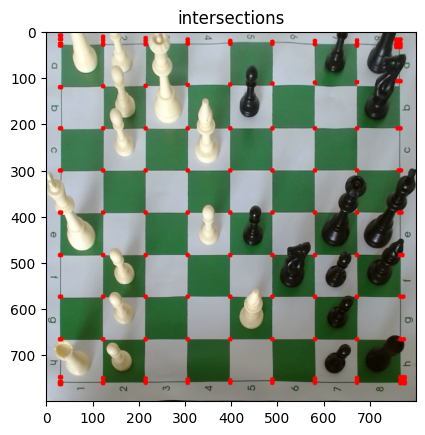

In [65]:
base = board.copy()
for point in points:
    x, y = point
    cv2.circle(base, (int(x), int(y)), 5, (255, 0, 0), -1)
plt.title("intersections")
plt.imshow(base)

In [66]:
def cluster_intersections(points, max_dist=55):
    Y = spatial.distance.pdist(points)
    Z = clstr.hierarchy.single(Y)
    T = clstr.hierarchy.fcluster(Z, max_dist, "distance")
    clusters = defaultdict(list)
    for i in range(len(T)):
        clusters[T[i]].append(points[i])
    clusters = clusters.values()
    clusters = map(lambda arr: (np.mean(np.array(arr)[:, 0]), np.mean(np.array(arr)[:, 1])), clusters)
    result = []
    for point in clusters:
        result.append([point[0], point[1]])
    return result
    
points_clustered = cluster_intersections(points)

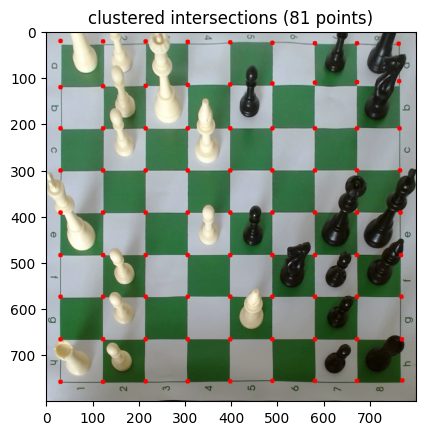

In [67]:
base = board.copy()
for point in points_clustered:
    x, y = point
    cv2.circle(base, (int(x), int(y)), 5, (255, 0, 0), -1)
plt.title("clustered intersections (81 points)")
plt.imshow(base)

In [68]:
len(points_clustered)

81

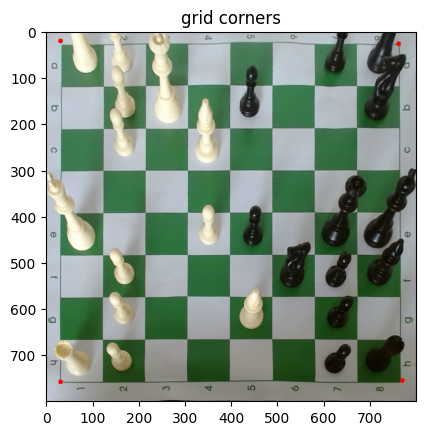

In [69]:
corners = find_corners(points_clustered)
base = board.copy()
for point in corners:
    x, y = point
    cv2.circle(base, (int(x), int(y)), 5, (255, 0, 0), -1)
plt.title("grid corners")
plt.imshow(base)

In [70]:
h, w = np.max(corners, axis=0)
x_start, y_start = np.min(corners, axis=0)
h, w, x_start, y_start

(np.float32(770.5385),
 np.float32(758.361),
 np.float32(31.0),
 np.float32(21.27372))

In [71]:
rows = 8
cols = 8

# Create linearly spaced points for the grid edges
x_points = np.linspace(x_start, w, cols + 1, dtype=int)
y_points = np.linspace(y_start, h, rows + 1, dtype=int)

# Create meshgrid to get the X,Y coordinates of all intersections
xv, yv = np.meshgrid(x_points, y_points)

# Extract and print the 4 corners for each grid square
grid_corners = []

for i in range(rows):
    for j in range(cols):
        top_left = (xv[i, j], yv[i, j])
        top_right = (xv[i, j + 1], yv[i, j])
        bottom_left = (xv[i + 1, j], yv[i + 1, j])
        bottom_right = (xv[i + 1, j + 1], yv[i + 1, j])

        
        corners = [top_left, top_right, bottom_left, bottom_right]
        grid_corners.append(corners)

grid_corners = np.array(grid_corners, dtype=np.float32).reshape(-1, 1, 2)
grid_corners = cv2.perspectiveTransform(grid_corners, M_inv)
grid_corners = grid_corners.reshape(-1, 4, 2)

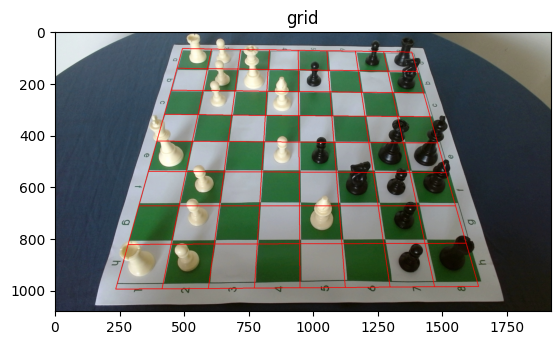

In [72]:
base = img.copy()
for square in grid_corners:
    top_left, top_right, bottom_left, bottom_right = square
    cv2.line(base, (int(top_left[0]), int(top_left[1])), (int(top_right[0]), int(top_right[1])), (255, 0, 0), 2)
    cv2.line(base, (int(top_right[0]), int(top_right[1])), (int(bottom_right[0]), int(bottom_right[1])), (255, 0, 0), 2)
    cv2.line(base, (int(bottom_right[0]), int(bottom_right[1])), (int(bottom_left[0]), int(bottom_left[1])), (255, 0, 0), 2)
    cv2.line(base, (int(bottom_left[0]), int(bottom_left[1])), (int(top_left[0]), int(top_left[1])), (255, 0, 0), 2)
plt.title("grid")
plt.imshow(base)

In [73]:
grid_corners[48]

array([[323.9256 , 674.1546 ],
       [479.46475, 674.21484],
       [282.494  , 823.     ],
       [448.83026, 822.4642 ]], dtype=float32)

In [74]:
squares = []
for square in grid_corners:
    x0, y0 = np.min(square, axis=0)
    x1, y1 = np.max(square, axis=0)
    squares.append((x0, y0, x1, y1))
print(squares[48])

(np.float32(282.494), np.float32(674.1546), np.float32(479.46475), np.float32(823.0))


In [75]:
squares_dict = {}
cols = "abcdefgh"
rows = "12345678"
square_names = [f'{col}{row}' for col in cols for row in rows]
print(square_names[48])

g1


In [76]:
for square, square_name in zip(squares, square_names):
    squares_dict[square_name] = {'piece': None, 'boundaries': np.array(square), 'score': None}

In [77]:
squares_dict['g1']

{'piece': None,
 'boundaries': array([282.494  , 674.1546 , 479.46475, 823.     ], dtype=float32),
 'score': None}

np.True_

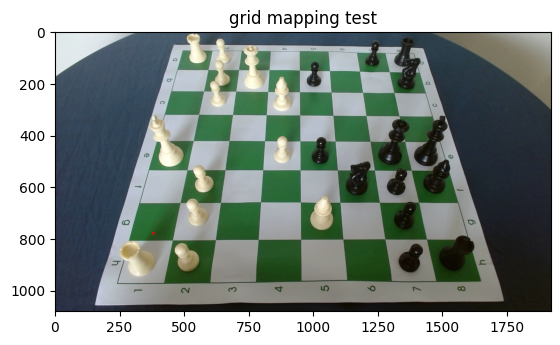

In [78]:
t = (380, 780)
base = img.copy()
cv2.circle(base, (int(t[0]), int(t[1])), 5, (255, 0, 0), -1)
plt.title("grid mapping test")
plt.imshow(base)
squares_dict['g1']['boundaries'][0] < t[0] <= squares_dict['g1']['boundaries'][2] and squares_dict['g1']['boundaries'][1] < t[1] <= squares_dict['g1']['boundaries'][3]

In [79]:
squares_dict

{'a1': {'piece': None,
  'boundaries': array([471.62064,  67.75047, 604.4354 , 145.11148], dtype=float32),
  'score': None},
 'a2': {'piece': None,
  'boundaries': array([588.7995 ,  69.44461, 716.7752 , 146.67955], dtype=float32),
  'score': None},
 'a3': {'piece': None,
  'boundaries': array([706.60223 ,  71.148224, 828.50006 , 148.23862 ], dtype=float32),
  'score': None},
 'a4': {'piece': None,
  'boundaries': array([823.7291 ,  72.84251, 940.18585, 149.78877], dtype=float32),
  'score': None},
 'a5': {'piece': None,
  'boundaries': array([ 939.61487,   74.52754, 1055.9781 ,  151.33008], dtype=float32),
  'score': None},
 'a6': {'piece': None,
  'boundaries': array([1050.1248 ,   76.2034 , 1171.1118 ,  152.86263], dtype=float32),
  'score': None},
 'a7': {'piece': None,
  'boundaries': array([1160.0345 ,   77.87016, 1285.5923 ,  154.38647], dtype=float32),
  'score': None},
 'a8': {'piece': None,
  'boundaries': array([1269.3491 ,   79.52789, 1399.4252 ,  155.90169], dtype=float32)

In [ ]:
from rfdetr import RFDETRMedium
model = RFDETRMedium(pretrain_weights=str(project_dir / 'models' / 'rfdetr_medium_v2' / 'checkpoint_best_total.pth'), num_classes=12)
label_list = ["B", "K", "N", "P", "Q", "R", "b", "k", "n", "p", "q", "r"]

[2026-06-26 19:04:46] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-26 19:04:46] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-06-26 19:04:46] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.


In [81]:
predictions = model.predict(base, threshold=0.5)

[2026-06-26 19:04:47] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


In [82]:
for pred in predictions:
    print(pred[0], pred[1], pred[2], pred[3])

[1476.3535  784.4203 1624.6646  930.4855] None 0.9365731 11
[1384.263    321.10895 1521.964    526.72327] None 0.9327359 7
[1243.8754  333.1448 1371.4305  518.8753] None 0.9314458 10
[361.07822 318.44922 504.52997 530.0717 ] None 0.93073446 1
[1418.6393  489.8236 1532.0507  633.7201] None 0.9250209 6
[1120.2748   497.078   1224.5059   637.81866] None 0.9244168 8
[ 981.4589   633.15137 1082.2139   774.3967 ] None 0.92297125 0
[719.8192    49.801105 813.69904  229.10326 ] None 0.9229486 4
[1318.5232    99.9918  1420.1116   230.52853] None 0.92233074 8
[242.91995 806.4138  395.249   951.8657 ] None 0.9205531 5
[1320.8616  816.2367 1426.0872  935.3783] None 0.91075784 9
[501.56186     4.1713996 591.0325    131.0709   ] None 0.9092378 5
[1305.2341    21.78356 1394.1436   142.15689] None 0.9084677 11
[836.77124 171.82236 922.38654 314.04877] None 0.9062244 0
[1192.5579    34.2258  1260.463    140.24469] None 0.9052017 9
[526.9965  512.26056 620.16595 627.6908 ] None 0.9036812 3
[456.89566 81

In [83]:
for square_name, square_info in squares_dict.items():
    x0, y0, x1, y1 = square_info['boundaries']
    for pred in predictions:
        xyxy = pred[0]
        bottom_center = ((xyxy[0] + xyxy[2]) / 2, xyxy[3])
        label = pred[3]
        score = pred[2]
        if x0 < bottom_center[0] < x1 and y0 < bottom_center[1] - 10 < y1:
            square_info['piece'] = label_list[label]
            square_info['score'] = score
            break

In [84]:
for square in squares_dict:
    if squares_dict[square]['piece'] is not None:
        print(square, squares_dict[square])

a1 {'piece': 'R', 'boundaries': array([471.62064,  67.75047, 604.4354 , 145.11148], dtype=float32), 'score': np.float32(0.9092378)}
a2 {'piece': 'P', 'boundaries': array([588.7995 ,  69.44461, 716.7752 , 146.67955], dtype=float32), 'score': np.float32(0.888138)}
a7 {'piece': 'p', 'boundaries': array([1160.0345 ,   77.87016, 1285.5923 ,  154.38647], dtype=float32), 'score': np.float32(0.9052017)}
a8 {'piece': 'r', 'boundaries': array([1269.3491 ,   79.52789, 1399.4252 ,  155.90169], dtype=float32), 'score': np.float32(0.9084677)}
b2 {'piece': 'P', 'boundaries': array([571.3794 , 145.11148, 706.60223, 230.80588], dtype=float32), 'score': np.float32(0.8755264)}
b3 {'piece': 'Q', 'boundaries': array([695.27167, 146.67955, 823.7291 , 232.19093], dtype=float32), 'score': np.float32(0.9229486)}
b5 {'piece': 'p', 'boundaries': array([ 940.18585,  149.78877, 1062.4923 ,  234.93611], dtype=float32), 'score': np.float32(0.89575267)}
b8 {'piece': 'n', 'boundaries': array([1285.5923 ,  154.38647, 1

In [85]:
def dict_to_fen(board_dict):
    # store FEN ranks in list to build FEN
    fen_ranks = []

    # FEN begins at rank 8, file a and goes down to rank 1, file h i.e. a8, b8... h1
    # iterate through ranks, counting empty files and noting pieces to build file strings
    for rank in '87654321':
        file_string = ''
        empty_count = 0

        for file in 'abcdefgh':
            square = f'{file}{rank}'
            piece = board_dict[square]['piece']

            if piece is None:
                empty_count += 1
            else:
                if empty_count > 0:
                    file_string += str(empty_count)
                    empty_count = 0
                file_string += piece

        if empty_count > 0:
            file_string += str(empty_count)

        fen_ranks.append(file_string)
    
    return '/'.join(fen_ranks)

In [86]:
fen = dict_to_fen(squares_dict)
print(fen)

rn2kb1r/p3qppp/5n2/1p2p1B1/2B1P3/1Q6/PPP2PPP/R3K2R
